<a href="https://colab.research.google.com/github/KhamidjonovRakhmatullo/computer_vision/blob/main/pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install torch

In [ ]:
import torch

In [ ]:
print(torch.__version__)

2.11.0+cpu


In [ ]:
print("CUDA available:", torch.cuda.is_available())

CUDA available: False


# 0D, 1D, 2D, 3D

In [ ]:
# -----------------------------
# 0D Tensor: Scalar
# -----------------------------
# Scalar means single value only.
# It has NO rows or columns.
scalar = torch.tensor(5)

print("scalar:", scalar)
print("shape:", scalar.shape)      # torch.Size([]) -> no shape because it is 0D
print("dimension:", scalar.ndim)   # 0 -> scalar is 0-dimensional
print("size:", scalar.size())      # same as shape

scalar: tensor(5)
shape: torch.Size([])
dimension: 0
size: torch.Size([])


In [ ]:
# -----------------------------
# 1D Tensor: Vector
# -----------------------------
# Vector means one-dimensional list of values.
# Example: [1, 2, 3]
vector = torch.tensor([1, 2, 3])

print("vector:", vector)
print("shape:", vector.shape)      # torch.Size([3]) -> 3 elements
print("dimension:", vector.ndim)   # 1 -> vector is 1-dimensional
print("size:", vector.size())      # same as shape

vector: tensor([1, 2, 3])
shape: torch.Size([3])
dimension: 1
size: torch.Size([3])


In [ ]:
# -----------------------------
# 2D Tensor: Matrix
# -----------------------------
# Matrix means rows and columns.
# Shape: [rows, columns]
MATRIX = torch.tensor([
    [1, 2, 3],
    [3, 4, 5],
])

print("MATRIX:", MATRIX)
print("shape:", MATRIX.shape) # torch.Size([2, 3]) -> 2 rows, 3 columns
print("dimension:", MATRIX.ndim)  # 2 -> matrix is 2-dimensional
print("size:", MATRIX.size()) # same as shape

MATRIX: tensor([[1, 2, 3],
        [3, 4, 5]])
shape: torch.Size([2, 3])
dimension: 2
size: torch.Size([2, 3])


In [ ]:
# -----------------------------
# 3D Tensor
# -----------------------------
# 3D tensor means multiple matrices stacked together.
# Here we stack 2 matrices.
tensor3d = torch.stack([MATRIX, MATRIX])

print("tensor3d:", tensor3d)
print("shape:", tensor3d.shape)    # torch.Size([2, 2, 3])
                                   # 2 -> number of matrices / stack size
                                   # 2 -> rows in each matrix
                                   # 3 -> columns in each matrix

print("dimension:", tensor3d.ndim) # 3 -> tensor is 3-dimensional
print("size:", tensor3d.size())    # same as shape

tensor3d: tensor([[[1, 2, 3],
         [3, 4, 5]],

        [[1, 2, 3],
         [3, 4, 5]]])
shape: torch.Size([2, 2, 3])
dimension: 3
size: torch.Size([2, 2, 3])


# RANDOM NUMBERS

In [ ]:
random_numbers = torch.rand(2, 3)

print('random numbers:', random_numbers)
print('data type:', random_numbers.dtype)
print("device of random_numbers:", random_numbers.device)

random numbers: tensor([[0.3829, 0.9593, 0.3904],
        [0.6009, 0.2566, 0.7936]])
data type: torch.float32
device of random_numbers: cpu


In [ ]:
print("zeros:", torch.zeros(2, 3))

zeros: tensor([[0., 0., 0.],
        [0., 0., 0.]])


In [ ]:
print("ones:", torch.ones(2, 3))

ones: tensor([[1., 1., 1.],
        [1., 1., 1.]])


# MATH with pytorch

In [ ]:
x = torch.tensor([ [1, 2], [3, 4] ])
y = torch.tensor([ [5, 6], [7, 8] ])

# Element-wise addition
print("Addition:", x + y)
print("------------------------")

# Element-wise multiplication
print("Multoplication:", x * y)
print("------------------------")


# Matrix multiplication (dot product)
# print("Matrix @ multiplication:", x @ y)
print("Matrix matmul multiplication:", torch.matmul(x, y))
print("------------------------")

Addition: tensor([[ 6,  8],
        [10, 12]])
------------------------
Multoplication: tensor([[ 5, 12],
        [21, 32]])
------------------------
Matrix matmul multiplication: tensor([[19, 22],
        [43, 50]])
------------------------


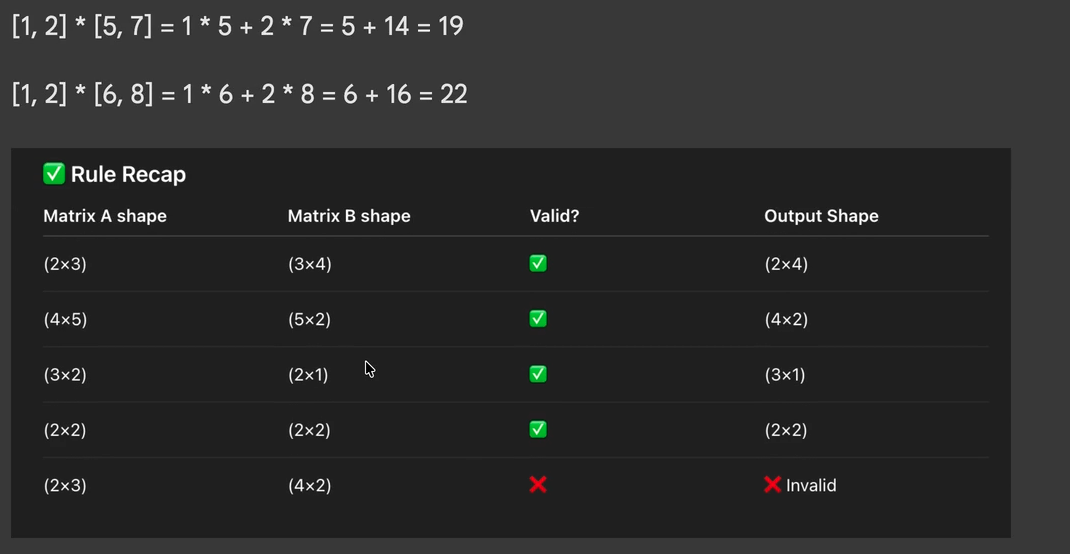

# Neural Network





# .`
# .`
# .`
# .`
# .`
# .`

# ■ Section 1: Import Libraries

In this section, we import the main tools we need for PyTorch.

### ▸ What we import

- `torch` → main PyTorch library
- `nn` → neural network building blocks
- `matplotlib.pyplot` → drawing graphs

<span style="color:green"><b>✓ Simple idea:</b></span>  
Before building a model, we need to import the libraries we will use.

In [ ]:
# Import PyTorch
# PyTorch is used for:
# - tensors
# - model building
# - training
# - saving/loading models
import torch


# Import nn from PyTorch
# nn means "neural network"
# It contains building blocks for neural networks:
# - layers
# - loss functions
# - model base class
from torch import nn


# Import Matplotlib
# We use pyplot to draw graphs
# Example: training data, testing data, predictions
import matplotlib.pyplot as plt


# Check PyTorch version
# This shows which PyTorch version is running in Colab
torch.__version__

'2.11.0+cpu'

# ■ Section 2: Device Setup

In this section, we choose where PyTorch will run the code.

### ▸ Device options

- <span style="color:blue"><b>● cpu</b></span> → normal computer processor
- <span style="color:green"><b>● cuda</b></span> → NVIDIA GPU

<span style="color:orange"><b>▲ Note:</b></span>  
For this simple Linear Regression model, CPU is enough.

<span style="color:green"><b>✓ Simple idea:</b></span>  
If GPU is available, use GPU. If not, use CPU.

In [ ]:
# Choose device automatically
# If CUDA GPU is available, use "cuda"
# Otherwise, use "cpu"
device = "cuda" if torch.cuda.is_available() else "cpu"


# Print which device we are using
print(f"Using device: {device}")

Using device: cpu


# ■ Section 3: Create Dataset

In this section, we create a simple Linear Regression dataset.

Linear Regression learns this formula:

`y = weight * X + bias`

### ▸ Real values

- <span style="color:blue"><b>● weight = 0.7</b></span>
- <span style="color:green"><b>● bias = 0.3</b></span>

<span style="color:green"><b>✓ Simple idea:</b></span>  
We create fake data using a known formula. Later, the model will try to learn this formula by itself.


## ■ What are Weight and Bias?

Linear Regression uses this formula:

`y = weight * X + bias`

- <span style="color:blue"><b>● weight</b></span> → controls how much `X` changes `y`
- <span style="color:green"><b>● bias</b></span> → controls the starting point of `y`

<span style="color:green"><b>✓ Simple idea:</b></span>  
The model learns the best `weight` and `bias` to make predictions close to the real answers.


-----

The model does not know the real `weight = 0.7` and `bias = 0.3`.

At first, it starts with random `weight` and `bias`.

Then it predicts:

`y_pred = weight * X + bias`

After that, it compares `y_pred` with the real `y`.

If the mistake is big, the optimizer updates `weight` and `bias`.

This process repeats many times until the model predicts `y` correctly.

In [ ]:
# Create real weight and bias
# These are the correct values used to create our fake dataset
#
# Formula:
# y = weight * X + bias   =>   y = multiply X, then add extra value
weight = 0.7
bias = 0.3


# Define the range for input values
# start = first X value
# end = stopping point, but 1 is NOT included
# step = distance between each value
start = 0
end = 1
step = 0.02


# Create X values
# torch.arange(start, end, step) creates numbers:
# 0.00, 0.02, 0.04, 0.06, ...
#
# unsqueeze(dim=1) adds one extra dimension
# This makes X shape compatible with nn.Linear()
X = torch.arange(start, end, step).unsqueeze(dim=1)


# Create y values using the linear formula
# y = 0.7 * X + 0.3
#
# y is the correct answer for each X value
# Later, the model will try to predict these y values by putting random w and b. And we will compare its prediction with y
y = weight * X + bias


# Show generated input values and labels
print("Generated X (features):", X)
print("Generated y (labels):", y)


# Split data into training and testing sets
# Training data: model learns from this data (80%)
# Testing data: model does NOT learn from this data (20%)
# We use testing data to check if the model can predict new unseen data
train_split = int(0.8 * len(X))


# First 80% of X and y go to training data
# The model will learn from this data
X_train, y_train = X[:train_split], y[:train_split]


# Remaining 20% of X and y go to testing data
# We use this data to check the model after training
X_test, y_test = X[train_split:], y[train_split:]


# Check how many values are in each dataset
len(X_train), len(y_train), len(X_test), len(y_test)

Generated X (features): tensor([[0.0000],
        [0.0200],
        [0.0400],
        [0.0600],
        [0.0800],
        [0.1000],
        [0.1200],
        [0.1400],
        [0.1600],
        [0.1800],
        [0.2000],
        [0.2200],
        [0.2400],
        [0.2600],
        [0.2800],
        [0.3000],
        [0.3200],
        [0.3400],
        [0.3600],
        [0.3800],
        [0.4000],
        [0.4200],
        [0.4400],
        [0.4600],
        [0.4800],
        [0.5000],
        [0.5200],
        [0.5400],
        [0.5600],
        [0.5800],
        [0.6000],
        [0.6200],
        [0.6400],
        [0.6600],
        [0.6800],
        [0.7000],
        [0.7200],
        [0.7400],
        [0.7600],
        [0.7800],
        [0.8000],
        [0.8200],
        [0.8400],
        [0.8600],
        [0.8800],
        [0.9000],
        [0.9200],
        [0.9400],
        [0.9600],
        [0.9800]])
Generated y (labels): tensor([[0.3000],
        [0.3140],
        [0.3280],

(40, 40, 10, 10)

# ■ Section 4: Plot Training, Testing, and Predictions

In this section, we create a helper function called `plot_predictions()`.

This function draws a scatter graph.

### ▸ Colors on the graph

- <span style="color:blue"><b>● Blue dots</b></span> → training data
- <span style="color:green"><b>● Green dots</b></span> → testing data
- <span style="color:red"><b>● Red dots</b></span> → model predictions

<span style="color:green"><b>✓ Simple idea:</b></span>  
We use this graph to visually compare the model predictions with the real test answers.

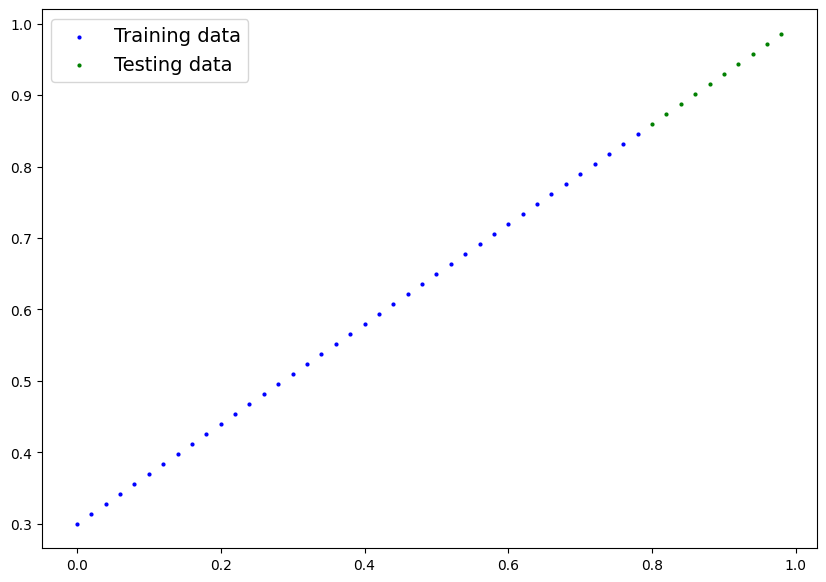

In [ ]:
# Create a helper function to draw our data and predictions
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):
    """
    Draw a scatter plot for:
    - training data
    - testing data
    - predictions, if predictions are given
    """

    # Create a new graph area
    # figsize=(10, 7) means:
    # width = 10
    # height = 7
    plt.figure(figsize=(10, 7))


    # Plot training data
    # train_data = X_train values shown on the x-axis
    # train_labels = y_train values shown on the y-axis
    #
    # c="b" -> blue color
    # s=4 -> dot size
    # label -> name shown in the legend
    plt.scatter(train_data,
                train_labels,
                c="b",
                s=4,
                label="Training data")


    # Plot testing data
    # test_data = X_test values shown on the x-axis
    # test_labels = y_test values shown on the y-axis
    #
    # c="g" -> green color
    # Green dots are the real correct answers for test data
    plt.scatter(test_data,
                test_labels,
                c="g",
                s=4,
                label="Testing data")


    # Plot predictions only if predictions are given
    # predictions = model's predicted y values
    #
    # Red dots are model guesses
    # We compare red dots with green dots
    if predictions is not None:
        plt.scatter(test_data,
                    predictions,
                    c="r",
                    s=4,
                    label="Predictions")


    # Show legend
    # Legend explains what each color means
    plt.legend(prop={"size": 14})


# Run the function without predictions
# Because predictions=None, this graph shows only:
# - blue training data
# - green testing data
plot_predictions()

# ■ Section 5: Create Linear Regression Model

In this section, we create our PyTorch model.

The model will learn this formula:

`y = X * weight + bias`

### ▸ What the model has

- <span style="color:blue"><b>● linear layer</b></span> → calculates `X * weight + bias`
- <span style="color:green"><b>● weight</b></span> → multiplier
- <span style="color:green"><b>● bias</b></span> → extra added value

<span style="color:orange"><b>▲ Important:</b></span>  
At first, `weight` and `bias` are random.

<span style="color:green"><b>✓ Simple idea:</b></span>  
The model starts with random `weight` and `bias`, then training updates them to make better predictions.

------

## ■ Why does `model_1(X_train)` run `forward()`?

`model_1` inherits from `nn.Module`.

In PyTorch, when we call the model like a function:

`model_1(X_train)`

PyTorch automatically runs:

`forward(X_train)`

So `X_train` becomes the `x` parameter inside `forward()`.

<span style="color:green"><b>✓ Simple idea:</b></span>  
Calling the model automatically sends data into `forward()`.

In [ ]:
# Create our own PyTorch model class
# We inherit from nn.Module because every PyTorch model should be based on nn.Module
class LinearRegressionModelV2(nn.Module):

    # Constructor
    # __init__ runs when we create the model object
    def __init__(self):
        super().__init__()

        # Create a linear layer
        #
        # Linear layer means:
        # y_pred = X * weight + bias
        #
        # in_features=1:
        # each input example has 1 value
        # Example: X = [[0.02], [0.04], [0.06]]
        #
        # out_features=1:
        # model returns 1 predicted value for each input
        # Example: y_pred = [[0.314], [0.328], [0.342]]
        #
        # PyTorch automatically creates:
        # - weight
        # - bias
        #
        # At first, weight and bias are random.
        # During training, optimizer will update them.
        self.linear_layer = nn.Linear(
            in_features=1,
            out_features=1
        )

    # forward() defines how input data moves through the model
    #
    # x = input data
    # self.linear_layer(x) calculates:
    # y_pred = x * weight + bias
    #
    # The output is the model prediction
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear_layer(x)


# Set random seed
# This makes the random starting weight and bias same every time we run the code
# It helps us get the same result while learning/testing
torch.manual_seed(42)


# Create the model object
# Now PyTorch creates random weight and bias inside linear_layer
model_1 = LinearRegressionModelV2()


# Show the model structure and current parameters
# state_dict() shows the current weight and bias values
model_1, model_1.state_dict()

(LinearRegressionModelV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

# ■ Section 6: Loss Function and Optimizer

In this section, we prepare two important training tools:

### ▸ Loss function

The loss function checks how wrong the model prediction is.

It compares:

`y_pred` vs `y_train`

### ▸ Optimizer

The optimizer updates the model parameters:

- <span style="color:blue"><b>● weight</b></span>
- <span style="color:green"><b>● bias</b></span>

<span style="color:green"><b>✓ Simple idea:</b></span>  
The loss function measures the mistake, and the optimizer updates `weight` and `bias` to reduce that mistake.

In [ ]:
# Create a loss function
#
# Loss function tells us how wrong the model predictions are.
#
# nn.L1Loss() calculates Mean Absolute Error (MAE):
#
# MAE = average of |prediction - real answer|
#
# Example:
# prediction = 0.8
# real answer = 1.0
# mistake = |0.8 - 1.0| = 0.2
#
# Small loss = good prediction
# Big loss = bad prediction
loss_fn = nn.L1Loss()


# Create an optimizer
#
# Optimizer updates the model parameters during training.
#
# In our model, the parameters are:
# - weight
# - bias
#
# SGD means Stochastic Gradient Descent.
# Simple meaning:
# it changes weight and bias step by step
# to make the loss smaller.
optimizer = torch.optim.SGD(
    params=model_1.parameters(),  # Tell optimizer which model parameters to update
    lr=0.01                       # Learning rate: how big each update step is
)

# ■ Section 7: Predictions Before Training

In this section, we use the model to make predictions before training.

At this moment:

- <span style="color:blue"><b>● weight</b></span> → random
- <span style="color:green"><b>● bias</b></span> → random
- <span style="color:red"><b>● predictions</b></span> → mostly wrong/random guesses

<span style="color:orange"><b>▲ Important:</b></span>  
The model has not learned yet, so red dots will probably be far from green dots.

<span style="color:green"><b>✓ Simple idea:</b></span>  
We first check how bad the model is before training. Later, after training, we compare again.

Text(0.5, 1.0, 'Predictions before training (red = random guesses)')

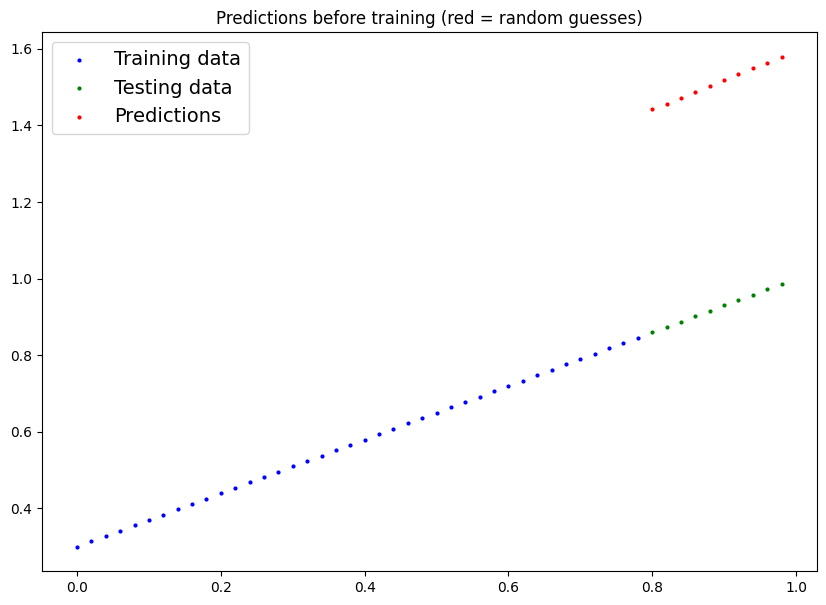

In [ ]:
# Put the model into evaluation mode
#
# eval() means:
# - we are NOT training now
# - we only want to use the model for prediction/testing
# - weight and bias will NOT be updated here
model_1.eval()


# Turn off gradient tracking
#
# During prediction/testing, we do not need gradients.
# Gradients are only needed during training/backpropagation.
#
# inference_mode() makes prediction:
# - faster
# - memory efficient
with torch.inference_mode():

    # Give X_test to the model
    #
    # The model uses its current weight and bias
    # to calculate predicted y values:
    #
    # y_pred = X_test * weight + bias
    #
    # IMPORTANT:
    # The model is not trained yet.
    # So current weight and bias are still random.
    # That means these predictions are mostly random guesses.
    y_preds_early = model_1(X_test)


# Draw the graph with early predictions
#
# Blue dots  = training data
# Green dots = real test answers
# Red dots   = model predictions before training
#
# Since the model is not trained yet,
# red dots will probably be far from green dots.
plot_predictions(predictions=y_preds_early)


# Add graph title
plt.title("Predictions before training (red = random guesses)")

# ■ Section 8: Training Loop

In this section, we train the model.

The model will repeat the learning process many times.

### ▸ Main training steps

1. Make prediction: `y_pred`
2. Compare with real answer: `y_train`
3. Calculate loss
4. Clear old gradients
5. Backpropagation
6. Update `weight` and `bias`

### ▸ Main testing steps

1. Make prediction on `X_test`
2. Compare with `y_test`
3. Calculate test loss

<span style="color:green"><b>✓ Simple idea:</b></span>  
Training updates `weight` and `bias`. Testing checks if the model is improving on unseen data.

In [ ]:
# Number of training rounds
#
# Epoch = one full learning round over the training data
# 1000 means the model will repeat the learning process 1000 times
epochs = 1000


# Move data to the selected device
#
# Model and data must be on the same device:
# - cpu
# - cuda
#
# If model is on CPU, data must be on CPU.
# If model is on GPU, data must be on GPU.
X_train = X_train.to(device)
y_train = y_train.to(device)

X_test = X_test.to(device)
y_test = y_test.to(device)


# Start training loop
# range(epochs) means repeat from 0 to 999
for epoch in range(epochs):

    # ======================================================
    # Training step
    # ======================================================

    # Put model into training mode
    # This tells PyTorch:
    # "We are training now."
    model_1.train()


    # 1. Forward pass
    #
    # Give training inputs to the model.
    # The model uses its own current weight and bias to predict y values.
    #
    # y_pred = X_train * weight + bias
    y_pred = model_1(X_train)


    # 2. Calculate training loss
    #
    # Compare model predictions with real training answers.
    #
    # y_pred = model answers
    # y_train = real answers
    #
    # loss tells us how wrong the model is.
    # MAE = average of |prediction - real answer|
    loss = loss_fn(y_pred, y_train)


    # 3. Clear old gradients
    #
    # PyTorch stores gradients after backward().
    # Before calculating new gradients, we must clear the old ones.
    # Now calculate fresh direction for this epoch.
    optimizer.zero_grad()


    # 4. Backpropagation
    #
    # Calculate how much weight and bias caused the mistake.
    #
    # This does NOT update weight and bias yet.
    # It only calculates gradients.
    #
    # gradient says:
    # weight should increase (or decrease)
    # bias should increase (or decrease)
    loss.backward()


    # 5. Update parameters
    #
    # Optimizer uses the gradients to update:
    # - weight
    # - bias
    #
    # Goal:
    # make the next loss smaller.
    optimizer.step()


    # ======================================================
    # Testing step
    # ======================================================

    # Put model into evaluation mode
    # This tells PyTorch:
    # "We are testing now, not training."
    model_1.eval()


    # Turn off gradient tracking
    #
    # During testing, we do not update weight and bias.
    # So we do not need gradients.
    with torch.inference_mode():

        # 1. Forward pass on test data
        #
        # Give unseen test inputs to the model.
        # Model predicts y values for X_test.
        test_pred = model_1(X_test)


        # 2. Calculate test loss
        #
        # Compare test predictions with real test answers.
        #
        # test_loss tells us how well the model works on new data.
        test_loss = loss_fn(test_pred, y_test)


    # Print progress every 100 epochs
    #
    # epoch % 100 == 0 means:
    # print at epoch 0, 100, 200, 300, ...
    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Train Loss: {loss} | Test Loss: {test_loss}")

Epoch: 0 | Train Loss: 0.0012645035749301314 | Test Loss: 0.013801807537674904
Epoch: 100 | Train Loss: 0.0012645035749301314 | Test Loss: 0.013801807537674904
Epoch: 200 | Train Loss: 0.0012645035749301314 | Test Loss: 0.013801807537674904
Epoch: 300 | Train Loss: 0.0012645035749301314 | Test Loss: 0.013801807537674904
Epoch: 400 | Train Loss: 0.0012645035749301314 | Test Loss: 0.013801807537674904
Epoch: 500 | Train Loss: 0.0012645035749301314 | Test Loss: 0.013801807537674904
Epoch: 600 | Train Loss: 0.0012645035749301314 | Test Loss: 0.013801807537674904
Epoch: 700 | Train Loss: 0.0012645035749301314 | Test Loss: 0.013801807537674904
Epoch: 800 | Train Loss: 0.0012645035749301314 | Test Loss: 0.013801807537674904
Epoch: 900 | Train Loss: 0.0012645035749301314 | Test Loss: 0.013801807537674904


# ■ Section 9: Final Predictions After Training

In this section, we use the trained model to make final predictions.

The model already learned better:

- <span style="color:blue"><b>● weight</b></span>
- <span style="color:green"><b>● bias</b></span>

Now we give `X_test` to the model and get `y_preds`.

<span style="color:green"><b>✓ Simple idea:</b></span>  
`X_test` goes into the trained model, and the model returns predicted `y` values.

In [ ]:
# Put the model into evaluation mode
#
# We are not training now.
# We only want to use the trained model to make predictions.
model_1.eval()


# Turn off gradient tracking
#
# We do not need gradients because:
# - we are not calculating backward()
# - we are not updating weight and bias
#
# This makes prediction faster and uses less memory.
with torch.inference_mode():

    # Give X_test to the trained model
    #
    # The model uses its learned weight and bias
    # to predict y values for the test inputs.
    y_preds = model_1(X_test)


# Show the predictions
#
# These are the model's final answers for X_test.
y_preds

tensor([[0.8600],
        [0.8739],
        [0.8878],
        [0.9018],
        [0.9157],
        [0.9296],
        [0.9436],
        [0.9575],
        [0.9714],
        [0.9854]])

# ■ Section 10: Plot Final Predictions

In this section, we draw the final graph after training.

The graph shows:

- <span style="color:blue"><b>● Blue dots</b></span> → training data
- <span style="color:green"><b>● Green dots</b></span> → real test data / correct answers
- <span style="color:red"><b>● Red dots</b></span> → model predictions after training

<span style="color:green"><b>✓ Simple idea:</b></span>  
If the red dots are close to the green dots, the model learned well.

Text(0.5, 1.0, 'Predictions after training')

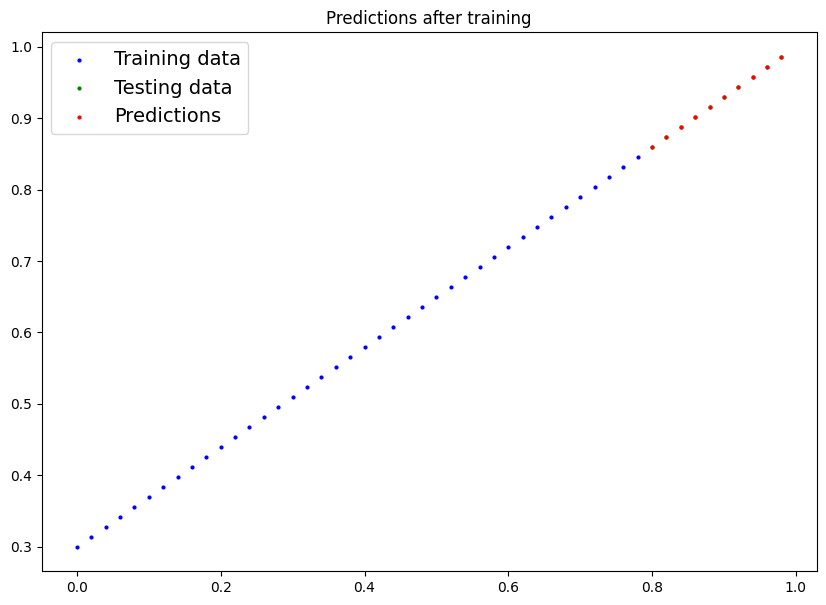

In [ ]:
# Plot training data, testing data, and final predictions
#
# Blue dots  = training data
# Green dots = real test data / correct answers
# Red dots   = model predictions after training
plot_predictions(predictions=y_preds)


# Add a title to the graph
#
# This tells us these predictions are AFTER training.
plt.title("Predictions after training")

# ■ Section 11: Save the Trained Model

In this section, we save the trained model parameters.

`state_dict()` contains the learned values:

- <span style="color:blue"><b>● weight</b></span>
- <span style="color:green"><b>● bias</b></span>

We save these values into a file called `trained_model.pth`.

<span style="color:green"><b>✓ Simple idea:</b></span>  
Saving the model means saving what the model learned.

In [ ]:
# Save the trained model parameters
# state_dict() contains the model's learned values:
# - weight
# - bias
#
# "trained_model.pth" is the file name where we save them
# .pth is a common PyTorch model file extension
torch.save(model_1.state_dict(), "trained_model.pth")

# ■ Section 12: Load the Saved Model

In this section, we load the saved trained model.

First, we create a new empty model with the same structure.

Then we load the saved parameters:

- <span style="color:blue"><b>● weight</b></span>
- <span style="color:green"><b>● bias</b></span>

<span style="color:orange"><b>▲ Important:</b></span>  
The new model must have the same structure as the saved model.

<span style="color:green"><b>✓ Simple idea:</b></span>  
Create the same model again, then put the saved learned values inside it.

In [ ]:
# Create a new empty model with the same structure
#
# IMPORTANT:
# This class must be the same as the model we saved.
#
# We are creating a new model object,
# but it does not have the trained values yet.
loaded_model = LinearRegressionModelV2()


# Load the saved trained parameters into the new model
#
# torch.load(...) reads the saved .pth file.
# load_state_dict(...) puts the saved parameters into loaded_model.
#
# In this model, the saved parameters are:
# - linear_layer.weight
# - linear_layer.bias
loaded_model.load_state_dict(torch.load("/content/trained_model.pth"))


# Put the loaded model into evaluation mode
#
# We are not training now.
# We only want to use the loaded model for prediction/testing.
loaded_model.eval()

with torch.inference_mode():
    loaded_model_preds = loaded_model(X_test)

loaded_model_preds

tensor([[0.8600],
        [0.8739],
        [0.8878],
        [0.9018],
        [0.9157],
        [0.9296],
        [0.9436],
        [0.9575],
        [0.9714],
        [0.9854]])

# ■ Super Simple Summary
- X goes into model.
- Model predicts y.
- Loss checks mistake.
- Backward calculates direction.
- Optimizer updates weight and bias.
- After many epochs, model learns the pattern.
- Then we save and load the learned model.
-
## We teach the model to find the best W and b, so it can use y_pred = XW + b to predict y.